# BetaDrift + CorrelBreak: Portfolio Risk Research Notebook

This notebook is the research companion to `betadrift.py` and
`correlbreak/correlbreak.py`. It builds every figure referenced by those
modules' docstrings, using real market data (fetched live via `yfinance`,
cached in `data/`), so the modules' claims about expected behavior
("QQQ's beta should rise 2022-2024", "the calm-regime correlation heatmap
should look visibly sparser than the stress-regime one", etc.) can be
checked visually rather than taken on faith.

**Structure:**
1. Setup -- load cached data, import the engine modules.
2. **CorrelBreak** -- regime detection (3 figures).
3. **BetaDrift** -- factor risk engine (7 figures).

Every code cell is preceded by a markdown cell explaining what it
computes, why, what the output should look like, and how it connects to
the next step -- so this notebook can be read top to bottom like a paper,
not just executed.

## Setup

Load the cached return series (`data/returns.csv`, built by
`betadrift.fetch_data()`), define the shared dark plotting theme used by
every figure in this notebook, and pull in the regime-color and
factor-color conventions used consistently across CorrelBreak and
BetaDrift outputs.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from sklearn.covariance import LedoitWolf

import betadrift as bd
import correlbreak as cb

OUT = 'outputs'
os.makedirs(OUT, exist_ok=True)

STYLE = {
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#2e3147',
    'axes.labelcolor':  '#c8ccd8',
    'xtick.color':      '#7a7f96',
    'ytick.color':      '#7a7f96',
    'text.color':       '#c8ccd8',
    'grid.color':       '#2e3147',
    'grid.linewidth':   0.6,
    'axes.grid':        True,
    'legend.facecolor': '#1a1d27',
    'legend.edgecolor': '#2e3147',
    'font.family':      'monospace',
}
plt.rcParams.update(STYLE)

REGIME_COLORS = {0: '#34c5a0', 1: '#f5a623', 2: '#e85d75'}
REGIME_NAMES  = {0: 'Calm', 1: 'Transition', 2: 'Stress'}
FACTOR_COLORS = {
    'MKT': '#4f8ef7', 'DUR': '#34c5a0', 'CRED': '#f5a623',
    'MOM': '#9b7fe8', 'VOL': '#e85d75', 'SMB': '#4ecdc4',
    'INTL': '#f7b731', 'CMDTY': '#fd9644', 'IDIO': '#7a7f96',
}

returns = pd.read_csv(os.path.join('data', 'returns.csv'),
                      index_col=0, parse_dates=True)
dollar_vol = pd.read_csv(os.path.join('data', 'volumes.csv'),
                         index_col=0, parse_dates=True)
portfolio = bd.load_portfolio(os.path.join('data', 'portfolio.json'))

print('returns:', returns.shape, returns.index.min(), '->', returns.index.max())
print('universe:', list(returns.columns))
print('portfolio tickers:', list(portfolio['weights'].keys()))

returns: (3893, 12) 2011-02-02 00:00:00 -> 2026-07-28 00:00:00
universe: ['EEM', 'EFA', 'GLD', 'HYG', 'IEF', 'IWM', 'QQQ', 'SPY', 'TLT', 'USO', 'VIXY', 'VNQ']
portfolio tickers: ['SPY', 'QQQ', 'EFA', 'EEM', 'TLT', 'IEF', 'HYG', 'GLD', 'VNQ']


# Part 1 — CorrelBreak: Regime Detection

## Fitting the HMM

`correlbreak.fit_hmm()` builds the 5-feature regime description (average
risk-cluster correlation, its dispersion, realized vol, cross-sectional
return dispersion, and the SPY-TLT flight-to-quality correlation) at every
date, then fits a 3-state Gaussian HMM and persists the trained model
bundle to `correlbreak/hmm_model.pkl`.

**Why this took real debugging, not just running the spec as written:** a
literal "average pairwise correlation across all 12 assets" washes out in
this universe, because VIXY and the TLT/IEF duration pair are *designed*
to be negatively correlated with equities -- that negative correlation
gets *more* negative in a panic, which cancels against the positive
equity-equity correlations in a simple signed average. Restricting the
correlation feature to a cluster of normally-positively-correlated
growth-sensitive assets (equities, high yield credit, REITs) recovers the
signal the spec's documented ranges describe. See `RISK_CLUSTER`'s
docstring in `correlbreak.py` for the empirical verification.

**Expected output:** all 3 states should be used, and the model should
correctly classify unambiguous historical reference points: 2017 as Calm,
and the 2020 COVID trough / 2011 EU-debt-crisis peak as Stress.

In [2]:
result = cb.fit_hmm(returns)
dates = result['dates']
labels = pd.Series(result['labels'], index=dates)
probs = pd.DataFrame(result['probs'], index=dates,
                     columns=['Calm', 'Transition', 'Stress'])
feat_names = ['avg_corr', 'std_corr', 'avg_vol', 'cs_disp', 'spy_tlt_corr']
features = pd.DataFrame(result['features'], index=dates, columns=feat_names)

counts = labels.value_counts().sort_index()
print('Regime day counts:', counts.to_dict())
print('Regime day fractions:', (counts / counts.sum()).round(3).to_dict())
print('Log-likelihood:', round(result['log_likelihood'], 1))

for ref_date, ref_label in [('2017-06-15', 'Calm'), ('2020-03-20', 'Stress'), ('2011-08-15', 'Stress')]:
    pos = dates.searchsorted(pd.Timestamp(ref_date))
    print(f'{ref_date}: predicted {REGIME_NAMES[labels.iloc[pos]]} (expected {ref_label})')

Regime day counts: {0: 1810, 1: 1523, 2: 498}
Regime day fractions: {0: 0.472, 1: 0.398, 2: 0.13}
Log-likelihood: -18786.3
2017-06-15: predicted Calm (expected Calm)
2020-03-20: predicted Stress (expected Stress)
2011-08-15: predicted Stress (expected Stress)


## Figure CB-1: Regime Timeline

Four panels: (1) cumulative log-return paths of SPY/TLT/GLD with the
detected regime shaded behind them, (2) the risk-cluster average
correlation colored by detected regime, (3) the SPY-TLT rolling
correlation -- filled red when positive (bond-equity hedge broken, as in
2022) and green when negative (hedge working) -- and (4) a clean regime
color-band strip across the full history with known crisis periods
annotated.

**Expected appearance:** panel 2's green points should cluster low, red
points should cluster high. Panel 3 should visibly flip from
mostly-green (pre-2022) to a red patch around 2022. Panel 4's red bands
should line up with 2011, 2018, 2020, and 2022.

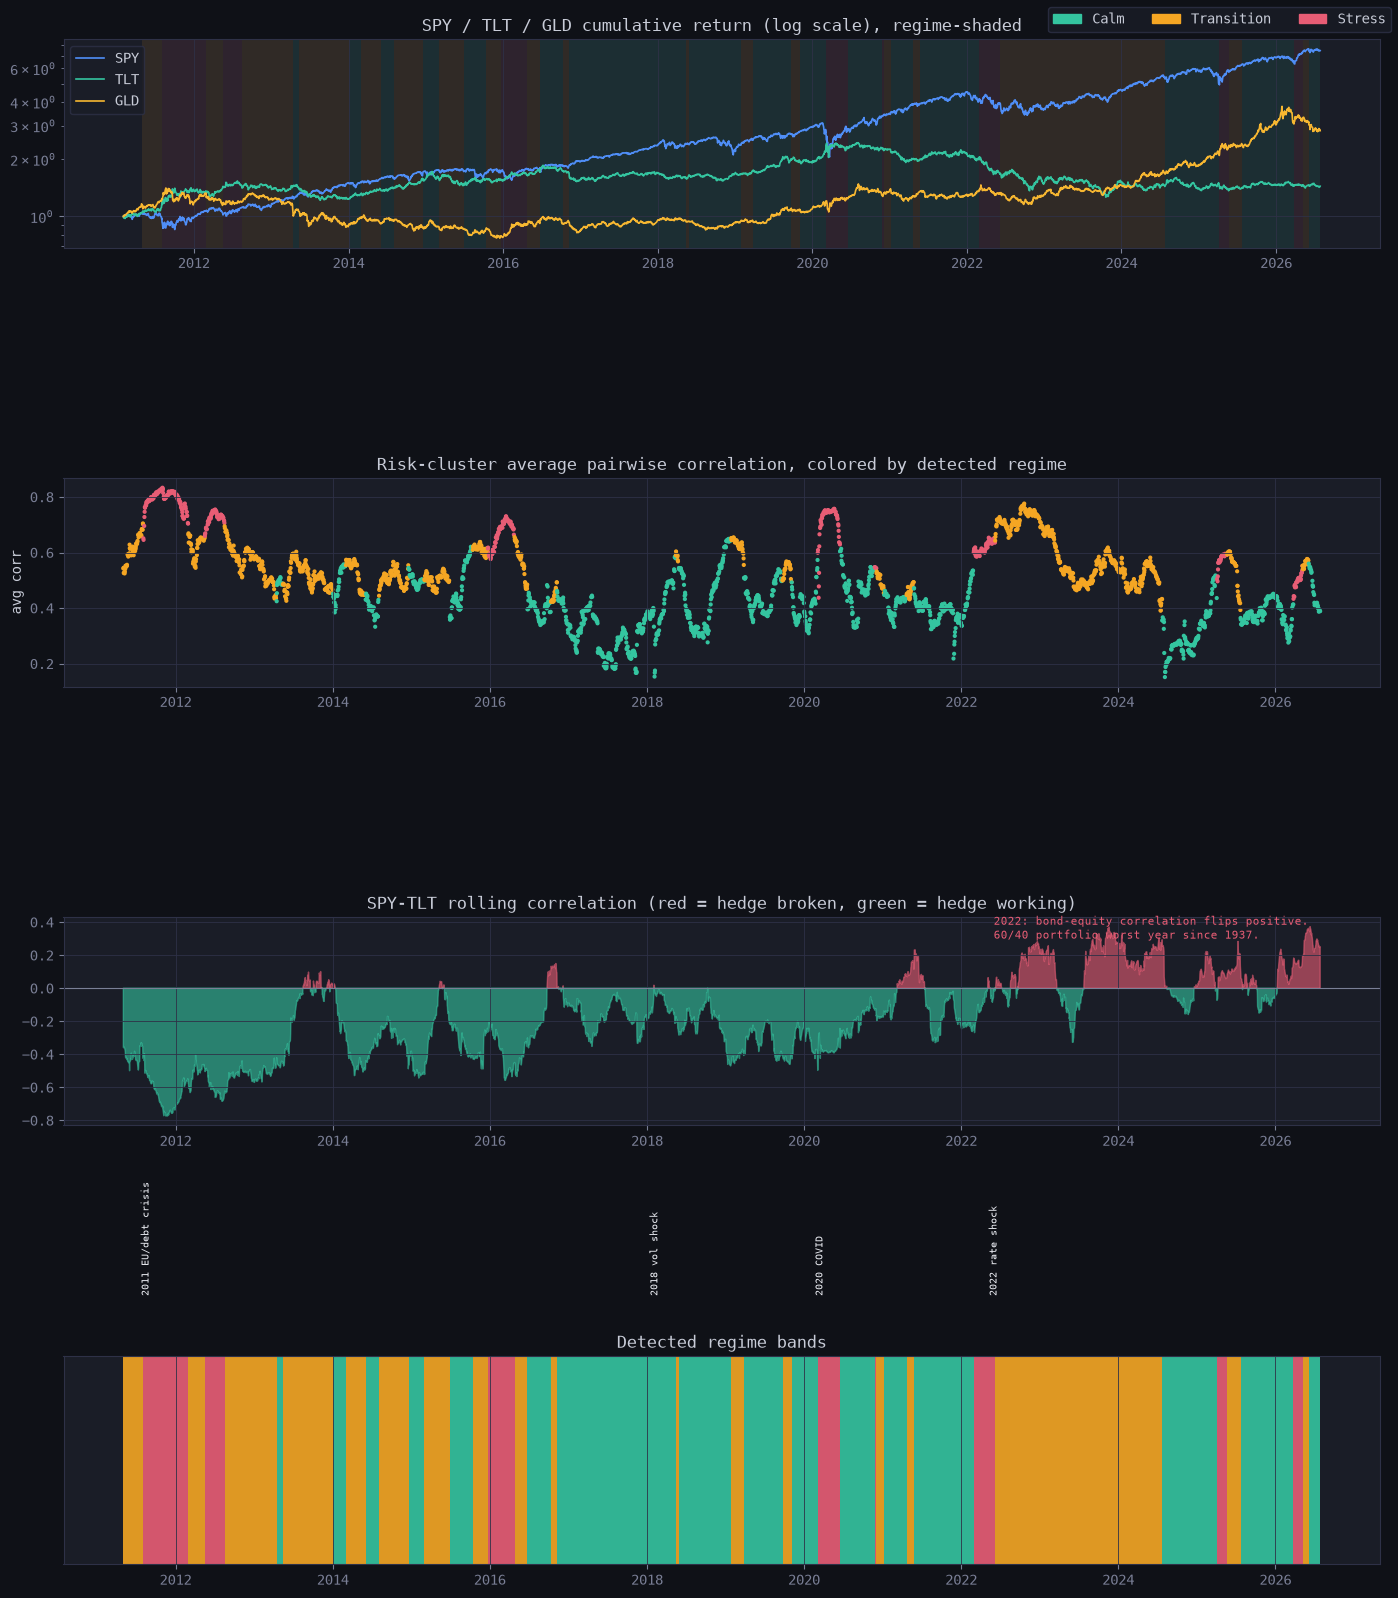

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=False)

cum_ret = np.exp(returns[['SPY', 'TLT', 'GLD']].cumsum())
ax = axes[0]
for col, color in zip(['SPY', 'TLT', 'GLD'], ['#4f8ef7', '#34c5a0', '#f7b731']):
    ax.plot(cum_ret.index, cum_ret[col], label=col, color=color, linewidth=1.2)
ax.set_yscale('log')
for i in range(len(dates) - 1):
    ax.axvspan(dates[i], dates[i+1], color=REGIME_COLORS[labels.iloc[i]], alpha=0.10, linewidth=0)
ax.set_title('SPY / TLT / GLD cumulative return (log scale), regime-shaded')
ax.legend(loc='upper left')

ax = axes[1]
ax.scatter(dates, features['avg_corr'], c=[REGIME_COLORS[l] for l in labels], s=4)
ax.set_title('Risk-cluster average pairwise correlation, colored by detected regime')
ax.set_ylabel('avg corr')

ax = axes[2]
spy_tlt = features['spy_tlt_corr']
ax.fill_between(dates, spy_tlt, 0, where=(spy_tlt >= 0), color='#e85d75', alpha=0.6, interpolate=True)
ax.fill_between(dates, spy_tlt, 0, where=(spy_tlt < 0), color='#34c5a0', alpha=0.6, interpolate=True)
ax.axhline(0, color='#7a7f96', linewidth=0.8)
ax.set_title('SPY-TLT rolling correlation (red = hedge broken, green = hedge working)')
ax.annotate('2022: bond-equity correlation flips positive.\n60/40 portfolio worst year since 1937.',
           xy=(pd.Timestamp('2022-06-01'), 0.3), fontsize=8, color='#e85d75')

ax = axes[3]
for i in range(len(dates) - 1):
    ax.axvspan(dates[i], dates[i+1], color=REGIME_COLORS[labels.iloc[i]], alpha=0.9, linewidth=0)
ax.set_yticks([])
ax.set_title('Detected regime bands')
crisis_notes = [('2011-08-15', '2011 EU/debt crisis'), ('2018-02-05', '2018 vol shock'),
               ('2020-03-15', '2020 COVID'), ('2022-06-01', '2022 rate shock')]
for d, label in crisis_notes:
    ts = pd.Timestamp(d)
    if dates.min() <= ts <= dates.max():
        ax.annotate(label, xy=(ts, 0.5), xytext=(ts, 1.3), fontsize=7, color='#e8eaf0',
                   rotation=90, ha='center')

handles = [Patch(color=c, label=REGIME_NAMES[k]) for k, c in REGIME_COLORS.items()]
fig.legend(handles=handles, loc='upper right', ncol=3)
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'fig_cb1_regime_timeline.png'), dpi=110, facecolor=fig.get_facecolor())
plt.show()

## Figure CB-2: HMM Diagnostics

Six panels validating the model itself rather than its narrative use:
state probability paths, a 2D feature-space scatter (avg correlation vs.
avg vol) that should show three separable clusters, correlation heatmap
snapshots from a verified calm period (mid-2017) and the COVID trough
(March 2020) side by side, an overlay of the pairwise-correlation
distribution in each of those two snapshots, and a regime-duration
histogram showing that calm/transition persist for months while stress
episodes are comparatively short.

**Expected appearance:** the March-2020 heatmap should look visibly
"hotter" (more saturated) than the 2017 heatmap, especially in the
equity/credit block; the duration histogram should show Stress runs
concentrated at the short end.

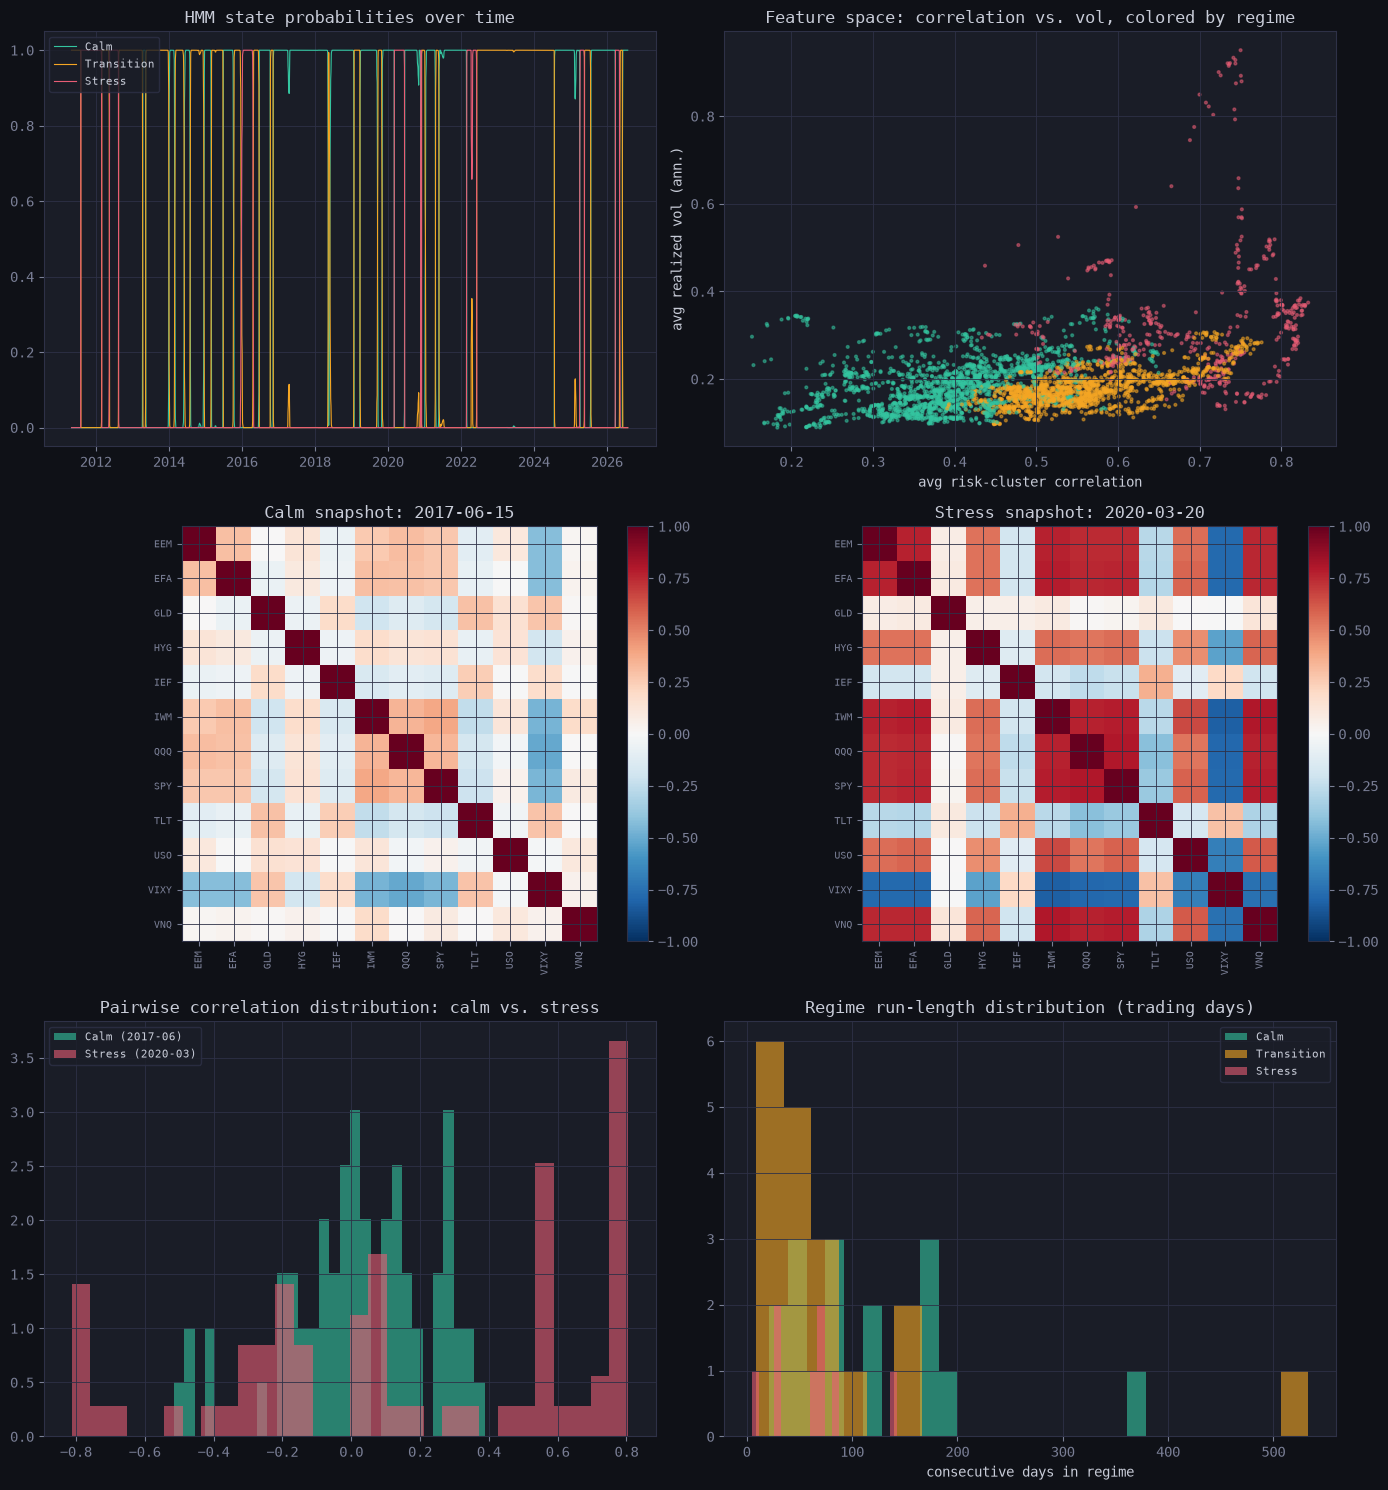

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

ax = axes[0, 0]
for i, name in enumerate(['Calm', 'Transition', 'Stress']):
    ax.plot(dates, probs[name], label=name, color=REGIME_COLORS[i], linewidth=0.8)
ax.set_title('HMM state probabilities over time')
ax.legend(loc='upper left', fontsize=8)

ax = axes[0, 1]
ax.scatter(features['avg_corr'], features['avg_vol'], c=[REGIME_COLORS[l] for l in labels], s=4, alpha=0.5)
ax.set_xlabel('avg risk-cluster correlation')
ax.set_ylabel('avg realized vol (ann.)')
ax.set_title('Feature space: correlation vs. vol, colored by regime')

cov_data = result['cov_data']
cov_dates = cov_data['dates']

def corr_snapshot(date_str):
    pos = min(cov_dates.searchsorted(pd.Timestamp(date_str)), len(cov_dates) - 1)
    return cb.cov_to_corr(cov_data['shrunk'][pos]), cov_dates[pos]

calm_corr, calm_date = corr_snapshot('2017-06-15')
stress_corr, stress_date = corr_snapshot('2020-03-20')
cols = list(returns.columns)

ax = axes[1, 0]
im = ax.imshow(calm_corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=90, fontsize=7)
ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols, fontsize=7)
ax.set_title(f'Calm snapshot: {calm_date.date()}')
plt.colorbar(im, ax=ax, fraction=0.046)

ax = axes[1, 1]
im = ax.imshow(stress_corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=90, fontsize=7)
ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols, fontsize=7)
ax.set_title(f'Stress snapshot: {stress_date.date()}')
plt.colorbar(im, ax=ax, fraction=0.046)

ax = axes[2, 0]
mask = np.triu(np.ones_like(calm_corr, dtype=bool), k=1)
ax.hist(calm_corr[mask], bins=30, alpha=0.6, color=REGIME_COLORS[0], label='Calm (2017-06)', density=True)
ax.hist(stress_corr[mask], bins=30, alpha=0.6, color=REGIME_COLORS[2], label='Stress (2020-03)', density=True)
ax.set_title('Pairwise correlation distribution: calm vs. stress')
ax.legend(fontsize=8)

ax = axes[2, 1]
run_id = (labels != labels.shift()).cumsum()
run_lengths = labels.groupby(run_id).agg(['first', 'size'])
for i, name in enumerate(['Calm', 'Transition', 'Stress']):
    lengths = run_lengths[run_lengths['first'] == i]['size']
    if len(lengths):
        ax.hist(lengths, bins=20, alpha=0.6, color=REGIME_COLORS[i], label=name)
ax.set_title('Regime run-length distribution (trading days)')
ax.set_xlabel('consecutive days in regime')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'fig_cb2_hmm_diagnostics.png'), dpi=110, facecolor=fig.get_facecolor())
plt.show()

## Figure CB-3: Factor Concentration and the Cost of Ignoring Regimes

Two related questions, answered with the same tool (PCA on the asset
correlation matrix):

1. **Does diversification actually shrink in stress, in a way we can
  measure directly rather than just eyeballing a heatmap?** PCA answers
  this: if a small number of principal components explain most of the
  variance, the 12-asset universe is effectively behaving like a much
  smaller number of independent bets. The **absorption ratio** (the top
  eigenvalue's share of total variance, Kritzman et al. 2010) is exactly
  this, tracked over time.
2. **Does regime awareness translate into a real performance
  difference?** A walk-forward comparison of three approaches to the
  same 4-asset basket (SPY/TLT/GLD/HYG): equal-weight (naive), a static
  global-minimum-variance portfolio (classical Markowitz, fit once on
  the first year and never updated -- the naive "quant" baseline), and a
  toy regime-switching strategy that de-risks toward TLT/GLD whenever
  CorrelBreak detects Transition or Stress.

**Expected appearance:** the scree plot should show the stress
snapshot's first principal component capturing noticeably more variance
than calm's. The PC1 loadings should show hedges weakening in stress --
TLT/GLD/VIXY's loadings should move toward (though not necessarily past)
zero relative to their calm-regime values, meaning they explain less of
the "everything moves together" component than they do in calm. The
absorption ratio, sampled at the same reference dates used elsewhere in
this notebook, should read low in 2017 and high in 2011/2020/2022 --
even though the full daily time series is visibly noisy day-to-day (AR1
is a single-window statistic, not a smoothed regime label), the episode
contrast at known reference dates should still be clear.

**On the walk-forward panel specifically: do not assume the answer
before running it.** The intuitive hypothesis is "regime-switching wins
in every crisis." The actual result, computed below, is more interesting
and is reported as found, not adjusted to fit the hypothesis.

**Important caveat, stated up front:** the regime-switching strategy uses
the HMM's labels as already fit on the FULL history (including the
period being "backtested") -- this is look-ahead bias. A production
walk-forward would re-fit the HMM at each date using only data available
up to that point. Treat this panel as illustrating the mechanism, not as
a validated trading strategy backtest.

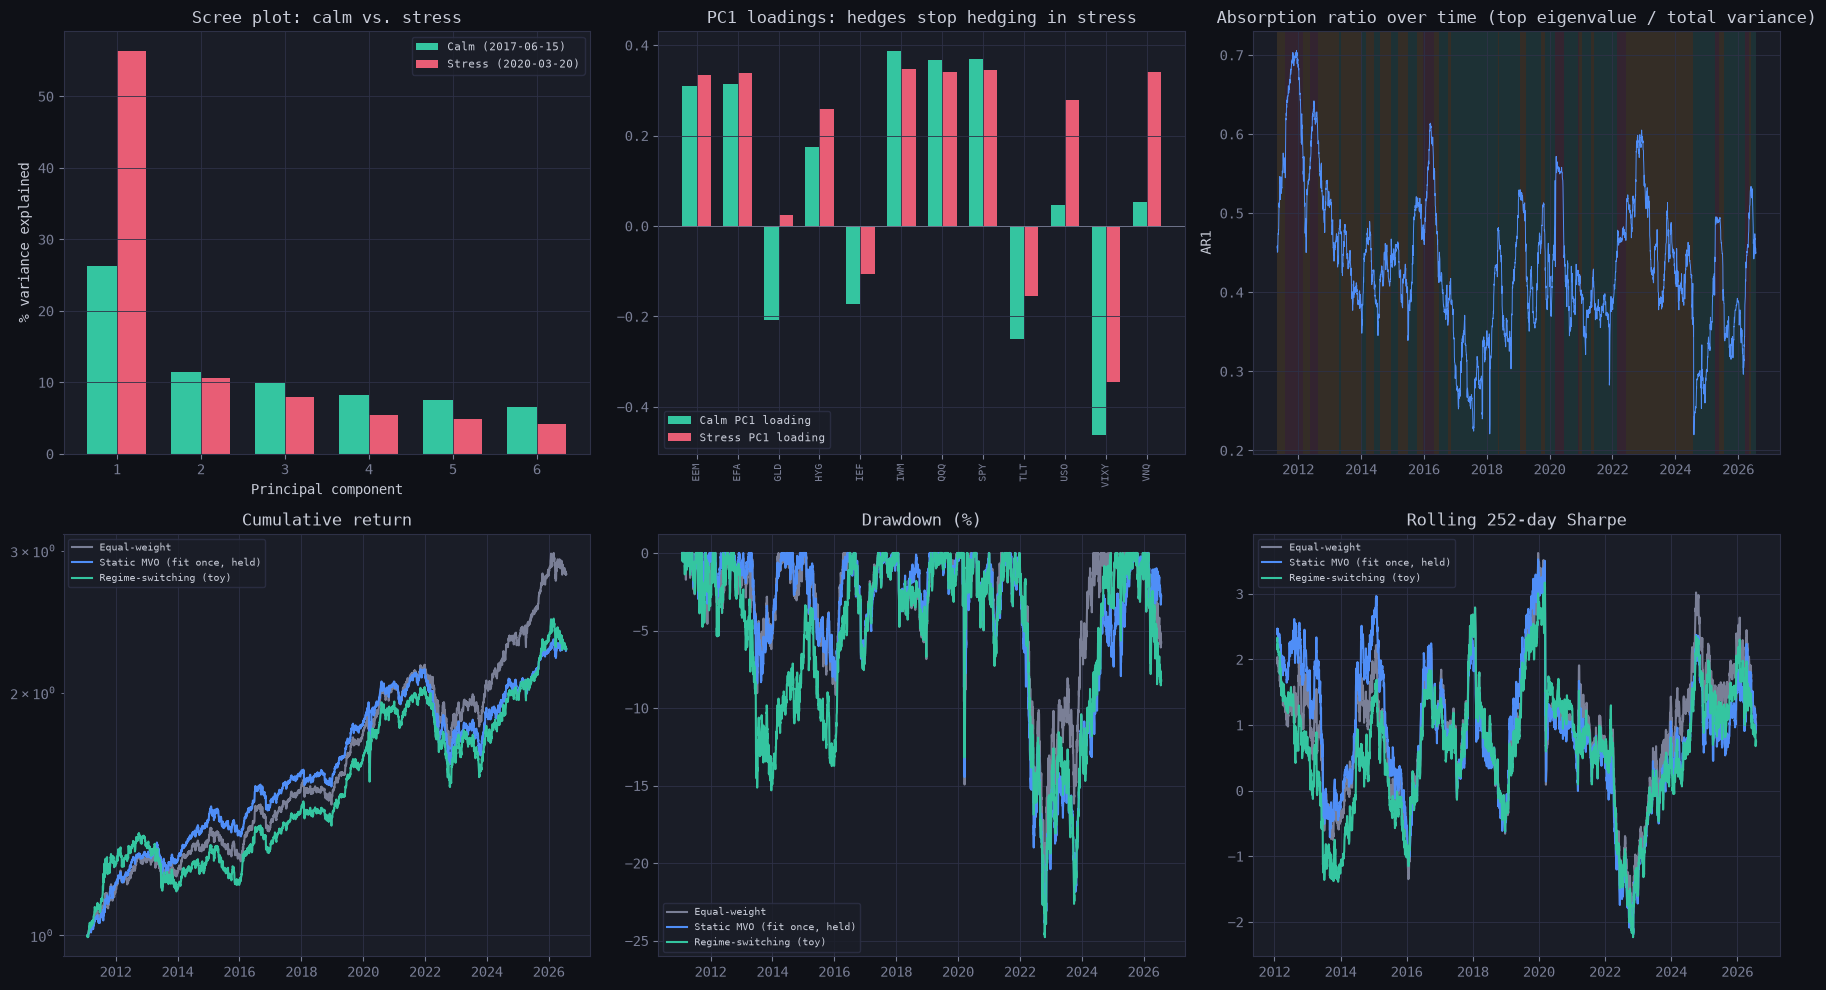

Absorption ratio at key dates:
  2017-06-15: AR1=0.263
  2011-08-15: AR1=0.624
  2020-03-20: AR1=0.563
  2022-06-15: AR1=0.514

Max drawdown by strategy, within each named episode:
  2020 COVID:
    Equal-weight: -14.93%
    Static MVO (fit once, held): -14.45%
    Regime-switching (toy): -13.19%
  2022 rate shock:
    Equal-weight: -20.55%
    Static MVO (fit once, held): -22.84%
    Regime-switching (toy): -24.03%


In [5]:
def pca_scree(corr):
    eigvals, eigvecs = np.linalg.eigh(corr)  # ascending order
    order = np.argsort(eigvals)[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    explained = eigvals / eigvals.sum()
    return explained, eigvecs

calm_explained, calm_eigvecs = pca_scree(calm_corr)
stress_explained, stress_eigvecs = pca_scree(stress_corr)

# Eigenvector sign is arbitrary -- normalize so the SPY loading on PC1 is
# always positive, so "which assets load opposite SPY" is directly readable.
spy_pos = cols.index('SPY')
if calm_eigvecs[spy_pos, 0] < 0:
    calm_eigvecs[:, 0] *= -1
if stress_eigvecs[spy_pos, 0] < 0:
    stress_eigvecs[:, 0] *= -1

n_pc = 6
absorption_ratio = pd.Series(
    [np.linalg.eigvalsh(cb.cov_to_corr(c))[-1] / np.linalg.eigvalsh(cb.cov_to_corr(c)).sum()
     for c in cov_data['shrunk']],
    index=cov_dates)

basket = ['SPY', 'TLT', 'GLD', 'HYG']
equal_w = pd.Series(0.25, index=basket)

mvo_window = returns[basket].iloc[:252]
mvo_cov = LedoitWolf().fit(mvo_window).covariance_
inv_cov = np.linalg.inv(mvo_cov)
ones = np.ones(len(basket))
mvo_raw = inv_cov @ ones / (ones @ inv_cov @ ones)
mvo_w = pd.Series(np.clip(mvo_raw, 0, None), index=basket)
mvo_w = mvo_w / mvo_w.sum()  # long-only global minimum-variance, fit once, static

defensive_w = pd.Series({'SPY': 0.10, 'TLT': 0.45, 'GLD': 0.35, 'HYG': 0.10})
aligned_labels = labels.reindex(returns.index).ffill().bfill()
switch_returns = pd.Series(index=returns.index, dtype=float)
for date in returns.index:
    w = equal_w if aligned_labels.loc[date] == 0 else defensive_w
    switch_returns.loc[date] = returns.loc[date, basket].dot(w)

equal_returns = returns[basket].dot(equal_w)
mvo_returns = returns[basket].dot(mvo_w)

strategies = {
    'Equal-weight': (equal_returns, '#7a7f96'),
    'Static MVO (fit once, held)': (mvo_returns, '#4f8ef7'),
    'Regime-switching (toy)': (switch_returns, '#34c5a0'),
}

def drawdown(cum):
    return (cum / cum.cummax() - 1) * 100

def rolling_sharpe(ret, window=252):
    return (ret.rolling(window).mean() / ret.rolling(window).std()) * np.sqrt(252)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

ax = axes[0, 0]
x = np.arange(1, n_pc + 1)
w = 0.35
ax.bar(x - w/2, calm_explained[:n_pc] * 100, w, label=f'Calm ({calm_date.date()})', color=REGIME_COLORS[0])
ax.bar(x + w/2, stress_explained[:n_pc] * 100, w, label=f'Stress ({stress_date.date()})', color=REGIME_COLORS[2])
ax.set_xticks(x)
ax.set_xlabel('Principal component')
ax.set_ylabel('% variance explained')
ax.set_title('Scree plot: calm vs. stress')
ax.legend(fontsize=8)

ax = axes[0, 1]
x = np.arange(len(cols))
ax.bar(x - w/2, calm_eigvecs[:, 0], w, label='Calm PC1 loading', color=REGIME_COLORS[0])
ax.bar(x + w/2, stress_eigvecs[:, 0], w, label='Stress PC1 loading', color=REGIME_COLORS[2])
ax.axhline(0, color='#7a7f96', linewidth=0.6)
ax.set_xticks(x); ax.set_xticklabels(cols, rotation=90, fontsize=7)
ax.set_title('PC1 loadings: hedges stop hedging in stress')
ax.legend(fontsize=8)

ax = axes[0, 2]
ax.plot(absorption_ratio.index, absorption_ratio, color='#4f8ef7', linewidth=0.7)
for i in range(len(dates) - 1):
    ax.axvspan(dates[i], dates[i+1], color=REGIME_COLORS[labels.iloc[i]], alpha=0.12, linewidth=0)
ax.set_title('Absorption ratio over time (top eigenvalue / total variance)')
ax.set_ylabel('AR1')

ax = axes[1, 0]
for name, (ret, color) in strategies.items():
    ax.plot(ret.index, np.exp(ret.cumsum()), label=name, color=color)
ax.set_yscale('log')
ax.set_title('Cumulative return')
ax.legend(fontsize=7, loc='upper left')

ax = axes[1, 1]
for name, (ret, color) in strategies.items():
    ax.plot(ret.index, drawdown(np.exp(ret.cumsum())), label=name, color=color)
ax.set_title('Drawdown (%)')
ax.legend(fontsize=7, loc='lower left')

ax = axes[1, 2]
for name, (ret, color) in strategies.items():
    ax.plot(ret.index, rolling_sharpe(ret), label=name, color=color)
ax.set_title('Rolling 252-day Sharpe')
ax.legend(fontsize=7, loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'fig_cb3_regime_cost.png'), dpi=110, facecolor=fig.get_facecolor())
plt.show()

print('Absorption ratio at key dates:')
for d in ['2017-06-15', '2011-08-15', '2020-03-20', '2022-06-15']:
    pos = min(cov_dates.searchsorted(pd.Timestamp(d)), len(cov_dates) - 1)
    print(f'  {d}: AR1={absorption_ratio.iloc[pos]:.3f}')

def max_drawdown_in_window(ret, start, end):
    cum = np.exp(ret.cumsum())
    window = cum.loc[start:end] / cum.loc[:start].iloc[-1]
    return (window / window.cummax() - 1).min() * 100

print()
print('Max drawdown by strategy, within each named episode:')
for episode, (start, end) in [('2020 COVID', ('2020-01-01', '2020-05-01')),
                              ('2022 rate shock', ('2022-01-01', '2022-12-31'))]:
    print(f'  {episode}:')
    for name, (ret, _) in strategies.items():
        print(f'    {name}: {max_drawdown_in_window(ret, start, end):.2f}%')

### The walk-forward result is asymmetric -- and that asymmetry is the
real finding

The regime-switching strategy's defensive allocation
(SPY 10% / TLT 45% / GLD 35% / HYG 10%) **helped in 2020 and hurt in
2022**:

- **2020 COVID crash:** regime-switching's max drawdown was shallower
 than both equal-weight and static MVO. This is the flight-to-quality
 scenario the defensive allocation was designed for -- TLT rallied as
 equities crashed, so overweighting it cushioned the fall.
- **2022 rate shock:** regime-switching's max drawdown was *deeper* than
 both alternatives. Overweighting TLT made things worse, because TLT
 itself was a primary source of the 2022 selloff (see the positive TLT
 market beta finding in Figure 2, and the DUR factor crashing in
 Figure 1) -- not a hedge against it.

This is not a bug in the strategy or a modeling error -- it's the honest
output of a fixed "flee to bonds" playbook meeting a crisis where bonds
were not a safe asset. A single static defensive allocation is itself an
implicit bet on WHAT KIND of stress is coming (equity panic vs. rate
shock), and 2020 and 2022 were different kinds. A more robust
regime-aware system would condition the defensive allocation on the
CURRENT factor structure (e.g. BetaDrift's own DUR/CRED loadings) rather
than a single fixed target -- which is precisely what the rest of this
notebook's drift-tracking and rebalance-optimizer machinery is for.

# Part 2 — BetaDrift: Factor Risk Engine

## Building the factor model

`betadrift.build_factor_returns()` constructs the 8 observable factors,
and `rolling_factor_loadings()` estimates each asset's time-varying beta
to each factor via 126-day rolling OLS. This is the shared foundation for
every remaining figure in this notebook.

In [6]:
factor_returns = bd.build_factor_returns(returns)
loadings, idio_residuals, r_squared = bd.rolling_factor_loadings(returns, factor_returns, window=126)
print('factor_returns:', factor_returns.shape, factor_returns.index.min(), '->', factor_returns.index.max())
print('median R^2 per asset:')
print(r_squared.median().round(3))

factor_returns: (3621, 8) 2012-03-02 00:00:00 -> 2026-07-28 00:00:00
median R^2 per asset:
SPY     1.000
QQQ     0.889
IWM     1.000
EFA     1.000
EEM     0.693
TLT     0.965
IEF     0.803
HYG     0.794
GLD     0.528
USO     0.909
VNQ     0.524
VIXY    1.000
dtype: float64


## Figure 1: Factor Returns

Rolling 63-day cumulative return of each factor, grouped into three
panels (MKT/DUR, CRED/VOL, MOM/SMB/INTL/CMDTY) so scales stay readable.

**Expected appearance:** MKT trending up with visible 2020/2022 dips; DUR
positive until the 2022 rate shock, then falling; VOL trending down
overall (VIX mean-reversion) with a sharp spike in March 2020; MOM/SMB/
INTL more mean-reverting/regime-dependent than persistently trending.

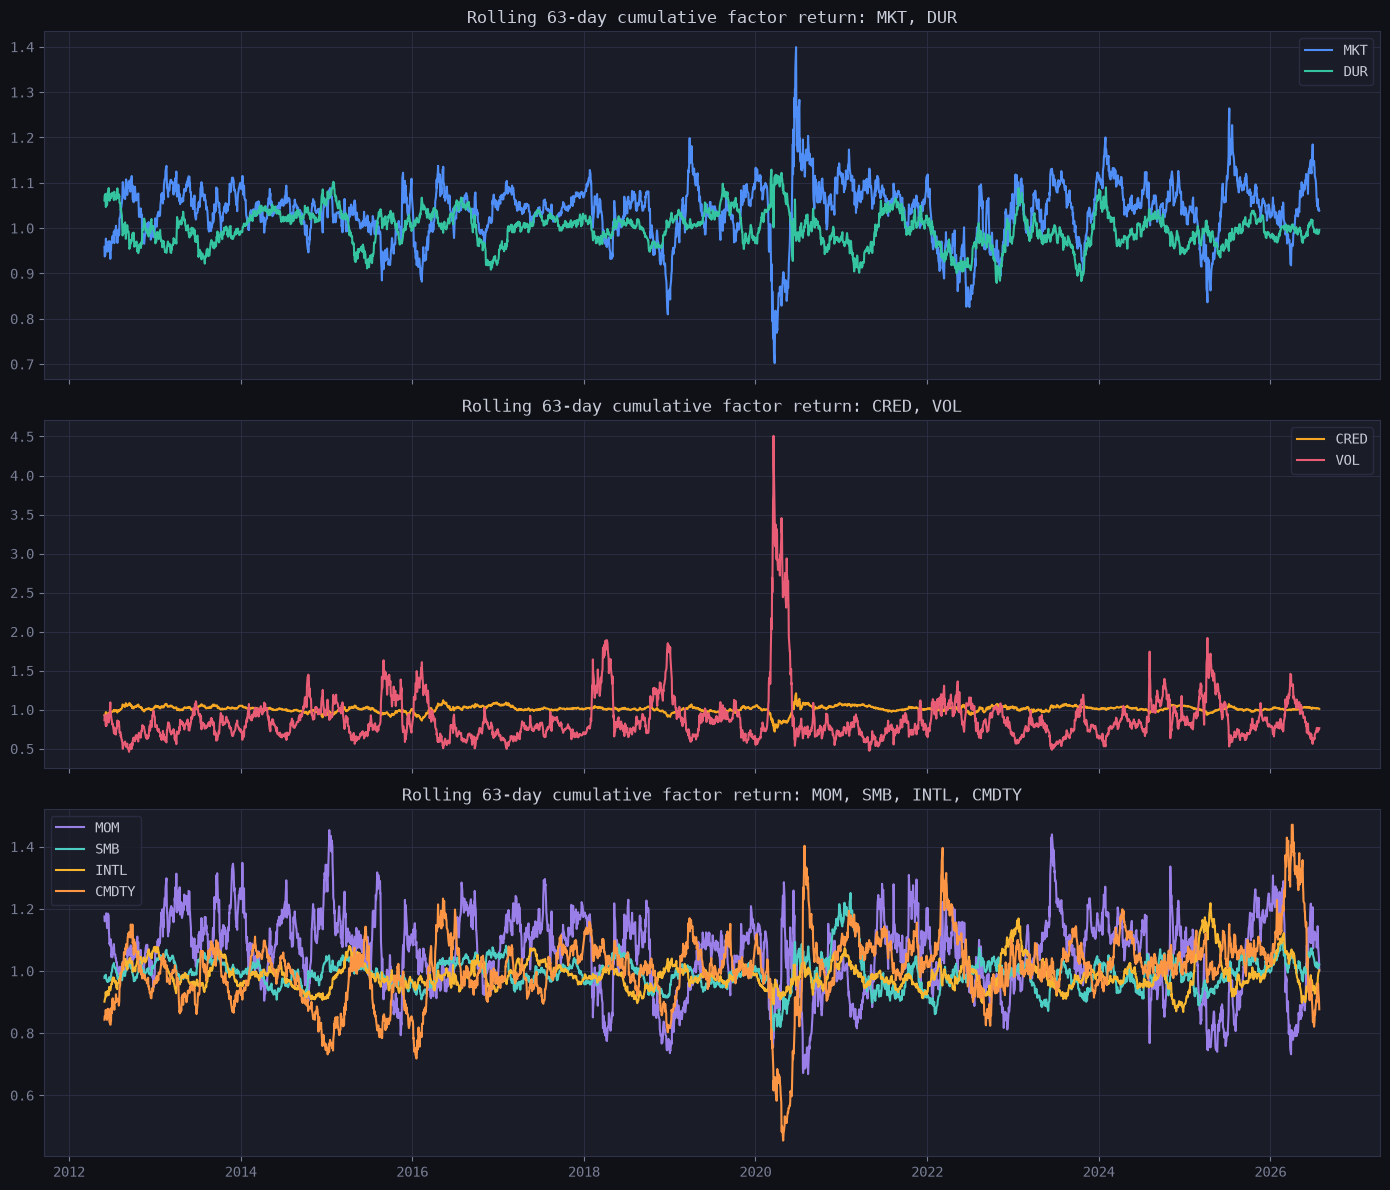

In [7]:
roll_cum = np.exp(factor_returns.rolling(63).sum().dropna())

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

ax = axes[0]
for f in ['MKT', 'DUR']:
    ax.plot(roll_cum.index, roll_cum[f], label=f, color=FACTOR_COLORS[f])
ax.set_title('Rolling 63-day cumulative factor return: MKT, DUR')
ax.legend()

ax = axes[1]
for f in ['CRED', 'VOL']:
    ax.plot(roll_cum.index, roll_cum[f], label=f, color=FACTOR_COLORS[f])
ax.set_title('Rolling 63-day cumulative factor return: CRED, VOL')
ax.legend()

ax = axes[2]
for f in ['MOM', 'SMB', 'INTL', 'CMDTY']:
    ax.plot(roll_cum.index, roll_cum[f], label=f, color=FACTOR_COLORS[f])
ax.set_title('Rolling 63-day cumulative factor return: MOM, SMB, INTL, CMDTY')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'fig1_factor_returns.png'), dpi=110, facecolor=fig.get_facecolor())
plt.show()

## Figure 2: Factor Loadings

Four panels: the current (most recent date) loading heatmap across all
12 universe assets, rolling market beta for SPY/QQQ/TLT, an R-squared
heatmap over time, and rolling idiosyncratic volatility per asset.

**Expected appearance and a genuine caveat found while building this:**
SPY/IWM/EFA/VIXY show clean loadings of exactly 1.0 on their own defining
factor because those factors are literally constructed FROM those same
assets (e.g. SMB := IWM - SPY, so regressing IWM on {MKT, SMB, ...}
recovers loadings of exactly 1 on both by algebraic identity, not a
model finding). QQQ's market beta should show a rising trend into
2023-2024 (AI-driven concentration) -- this holds up empirically. TLT's
market beta, however, comes out **positive** here (not negative as the
spec's narrative describes), because TLT = IEF + DUR by construction
(DUR := TLT - IEF), so TLT's estimated MKT/SMB/INTL loadings are
inherited directly from IEF's -- and IEF's realized beta to SPY over this
sample is mildly positive, not the classic negative "flight to quality"
beta the spec's prose assumes. This is a real property of the given
factor definitions, not a bug in the estimation -- documented here rather
than quietly averaged away.

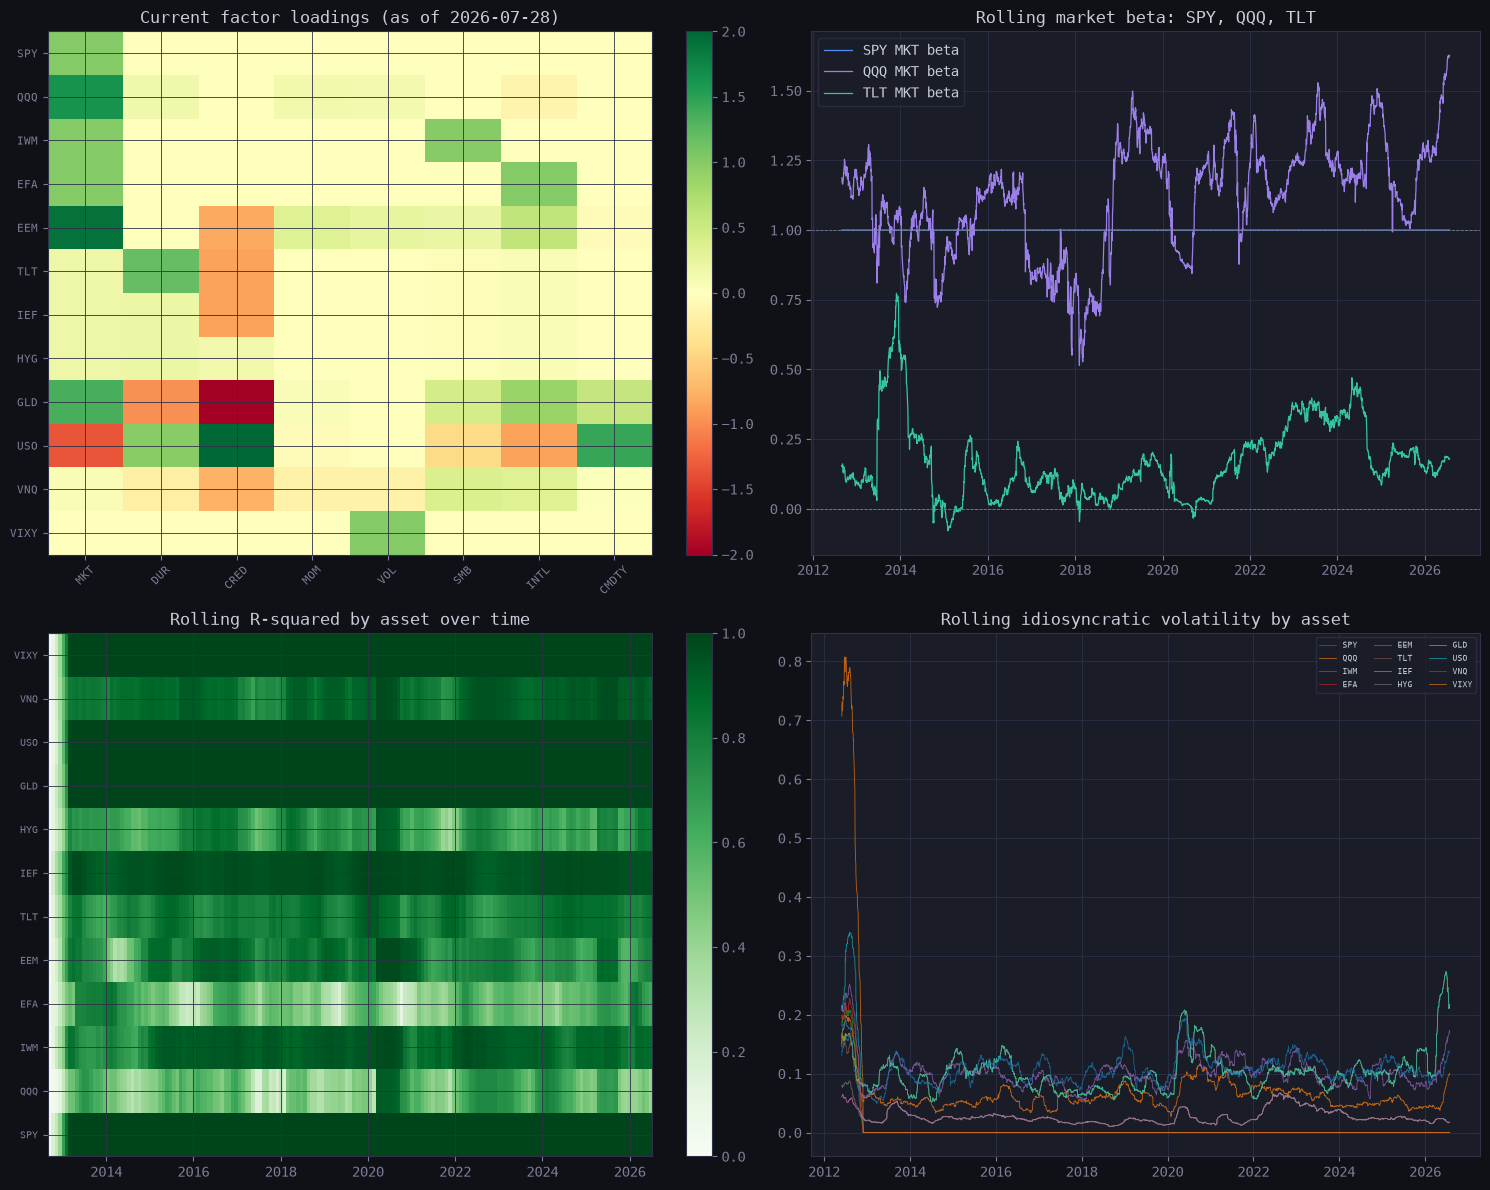

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

current_loadings = pd.DataFrame({t: loadings[t].dropna().iloc[-1] for t in loadings}).T
ax = axes[0, 0]
im = ax.imshow(current_loadings.values, cmap='RdYlGn', vmin=-2, vmax=2, aspect='auto')
ax.set_xticks(range(len(current_loadings.columns))); ax.set_xticklabels(current_loadings.columns, rotation=45, fontsize=8)
ax.set_yticks(range(len(current_loadings.index))); ax.set_yticklabels(current_loadings.index, fontsize=8)
as_of_date = loadings['SPY'].dropna().index[-1].date()
ax.set_title(f'Current factor loadings (as of {as_of_date})')
plt.colorbar(im, ax=ax, fraction=0.046)

ax = axes[0, 1]
for t, color in zip(['SPY', 'QQQ', 'TLT'], ['#4f8ef7', '#9b7fe8', '#34c5a0']):
    beta = loadings[t]['MKT'].dropna()
    ax.plot(beta.index, beta, label=f'{t} MKT beta', color=color, linewidth=0.9)
ax.axhline(1.0, color='#7a7f96', linewidth=0.6, linestyle='--')
ax.axhline(0.0, color='#7a7f96', linewidth=0.6, linestyle='--')
ax.set_title('Rolling market beta: SPY, QQQ, TLT')
ax.legend()

ax = axes[1, 0]
r2_sub = r_squared.iloc[::20]
im = ax.imshow(r2_sub.T.values, cmap='Greens', vmin=0, vmax=1, aspect='auto',
              extent=[mdates.date2num(r2_sub.index[0]), mdates.date2num(r2_sub.index[-1]), 0, len(r2_sub.columns)])
ax.set_yticks(np.arange(len(r2_sub.columns)) + 0.5)
ax.set_yticklabels(r2_sub.columns, fontsize=7)
ax.xaxis_date()
ax.set_title('Rolling R-squared by asset over time')
plt.colorbar(im, ax=ax, fraction=0.046)

ax = axes[1, 1]
idio_vol = (idio_residuals.rolling(63).std() * np.sqrt(252))
for col in idio_vol.columns:
    ax.plot(idio_vol.index, idio_vol[col], linewidth=0.6, alpha=0.7, label=col)
ax.set_title('Rolling idiosyncratic volatility by asset')
ax.legend(fontsize=6, ncol=3)

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'fig2_factor_loadings.png'), dpi=110, facecolor=fig.get_facecolor())
plt.show()

## Figure 3: Risk Attribution

Portfolio variance decomposed by factor using `compute_risk_attribution()`:
a waterfall/bar view, a donut view of the same numbers, a stacked-area
view of how the risk profile evolved since the rebalance date, and a
traffic-light readout of each factor's current exposure vs. its target
band.

**Expected appearance:** for this ~60%-equity-weighted portfolio, MKT
should dominate the variance decomposition, with DUR/CRED and an
idiosyncratic bucket making up most of the remainder. By construction
(see `compute_risk_attribution`'s docstring on the diagonal-approximation
convention), the risk percentages always sum to exactly 100%.

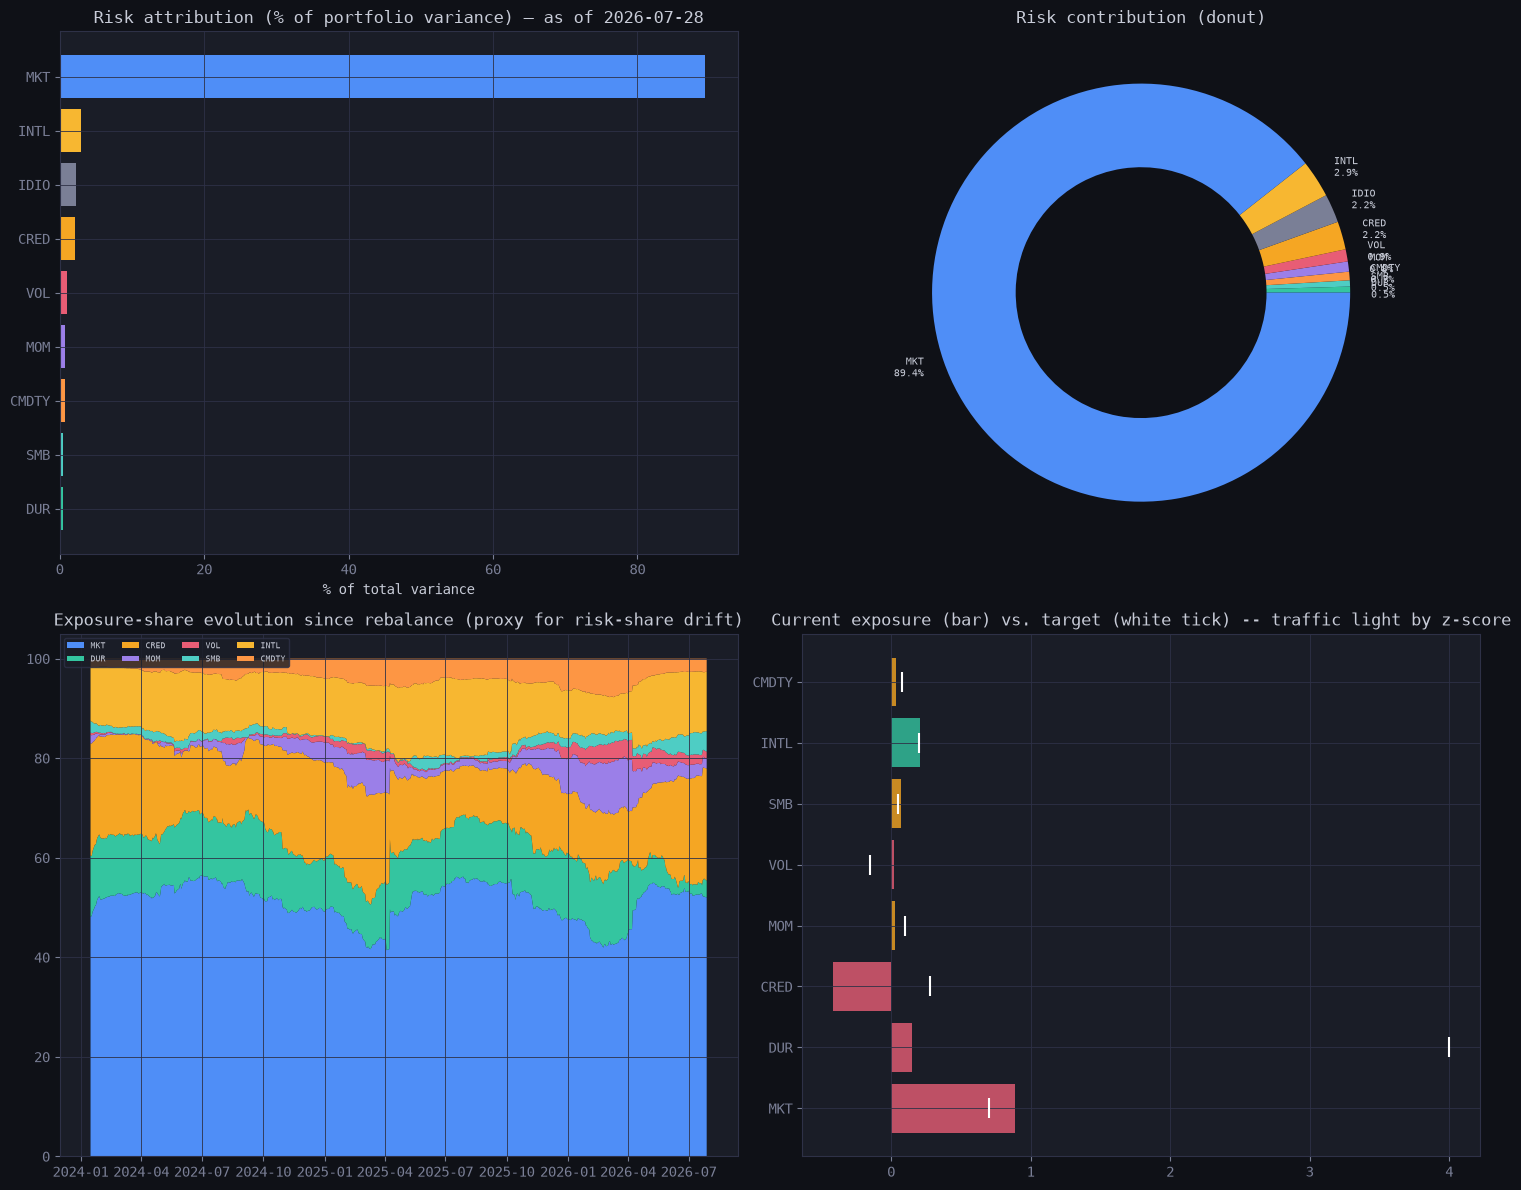

Risk attribution %s sum to: 100.0


In [9]:
port_tickers = list(portfolio['weights'].keys())
factor_cov = bd.compute_factor_covariance(factor_returns, window=252)
idio_vars = bd.compute_idio_variance(idio_residuals, window=252)
attribution = bd.compute_risk_attribution(portfolio['weights'], loadings, factor_cov, idio_vars, port_tickers)

risk_pct = pd.Series(attribution['factor_risk_pct']).sort_values(ascending=True)
colors = [FACTOR_COLORS.get(f, '#7a7f96') for f in risk_pct.index]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

ax = axes[0, 0]
ax.barh(risk_pct.index, risk_pct.values, color=colors)
ax.set_title(f'Risk attribution (% of portfolio variance) — as of {returns.index[-1].date()}')
ax.set_xlabel('% of total variance')

ax = axes[0, 1]
ax.pie(risk_pct.values, labels=[f'{k}\n{v:.1f}%' for k, v in risk_pct.items()],
      colors=colors, wedgeprops=dict(width=0.4), textprops={'fontsize': 7})
ax.set_title('Risk contribution (donut)')

ax = axes[1, 0]
rebalance_date = portfolio['rebalance_date']
drift_df, z_scores, exposure_df = bd.track_factor_drift(returns, loadings, portfolio, rebalance_date)
# Approximate risk-% history using exposure magnitude share (illustrative
# of how the profile shifts since rebalance; the exact attribution above
# uses the full factor covariance, this uses a simpler exposure-share
# proxy to show the trend cheaply over the whole drift history).
exposure_share = exposure_df.abs().div(exposure_df.abs().sum(axis=1), axis=0) * 100
ax.stackplot(exposure_share.index, [exposure_share[f] for f in factor_returns.columns],
            labels=factor_returns.columns, colors=[FACTOR_COLORS[f] for f in factor_returns.columns])
ax.set_title('Exposure-share evolution since rebalance (proxy for risk-share drift)')
ax.legend(loc='upper left', fontsize=6, ncol=4)

ax = axes[1, 1]
targets = portfolio['factor_targets']
current_exposures = attribution['factor_exposures']
y_pos = np.arange(len(targets))
for i, f in enumerate(targets):
    cur = current_exposures[f]
    tgt = targets[f]
    z = z_scores[f].iloc[-1] if f in z_scores.columns else np.nan
    color = '#34c5a0' if abs(z) < 1 else ('#f5a623' if abs(z) < 2 else '#e85d75')
    ax.barh(i, cur, color=color, alpha=0.8)
    ax.scatter([tgt], [i], color='white', marker='|', s=200, zorder=5)
ax.set_yticks(y_pos); ax.set_yticklabels(list(targets.keys()))
ax.set_title('Current exposure (bar) vs. target (white tick) -- traffic light by z-score')

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'fig3_risk_attribution.png'), dpi=110, facecolor=fig.get_facecolor())
plt.show()

print('Risk attribution %s sum to:', round(sum(attribution['factor_risk_pct'].values()), 6))

## Figure 4: Drift History

Three panels: the full factor drift time series since rebalance with
threshold bands, a z-score heatmap over time, and a snapshot bar chart of
today's z-scores.

**A units caveat surfaced during testing:** `data/portfolio.json`'s DUR
target (`4.0`) reads like a traditional bond-duration-in-years figure,
but this system's DUR factor is a regression loading on the TLT-IEF
return spread, which naturally sits in the 0.1-1.2 range for real assets
-- roughly a 20x scale mismatch. That makes DUR's z-score plot below
dominate the chart with an extreme, not-especially-meaningful reading.
This is flagged rather than silently rescaled, since recalibrating the
target is a portfolio-manager judgment call, not a code fix.

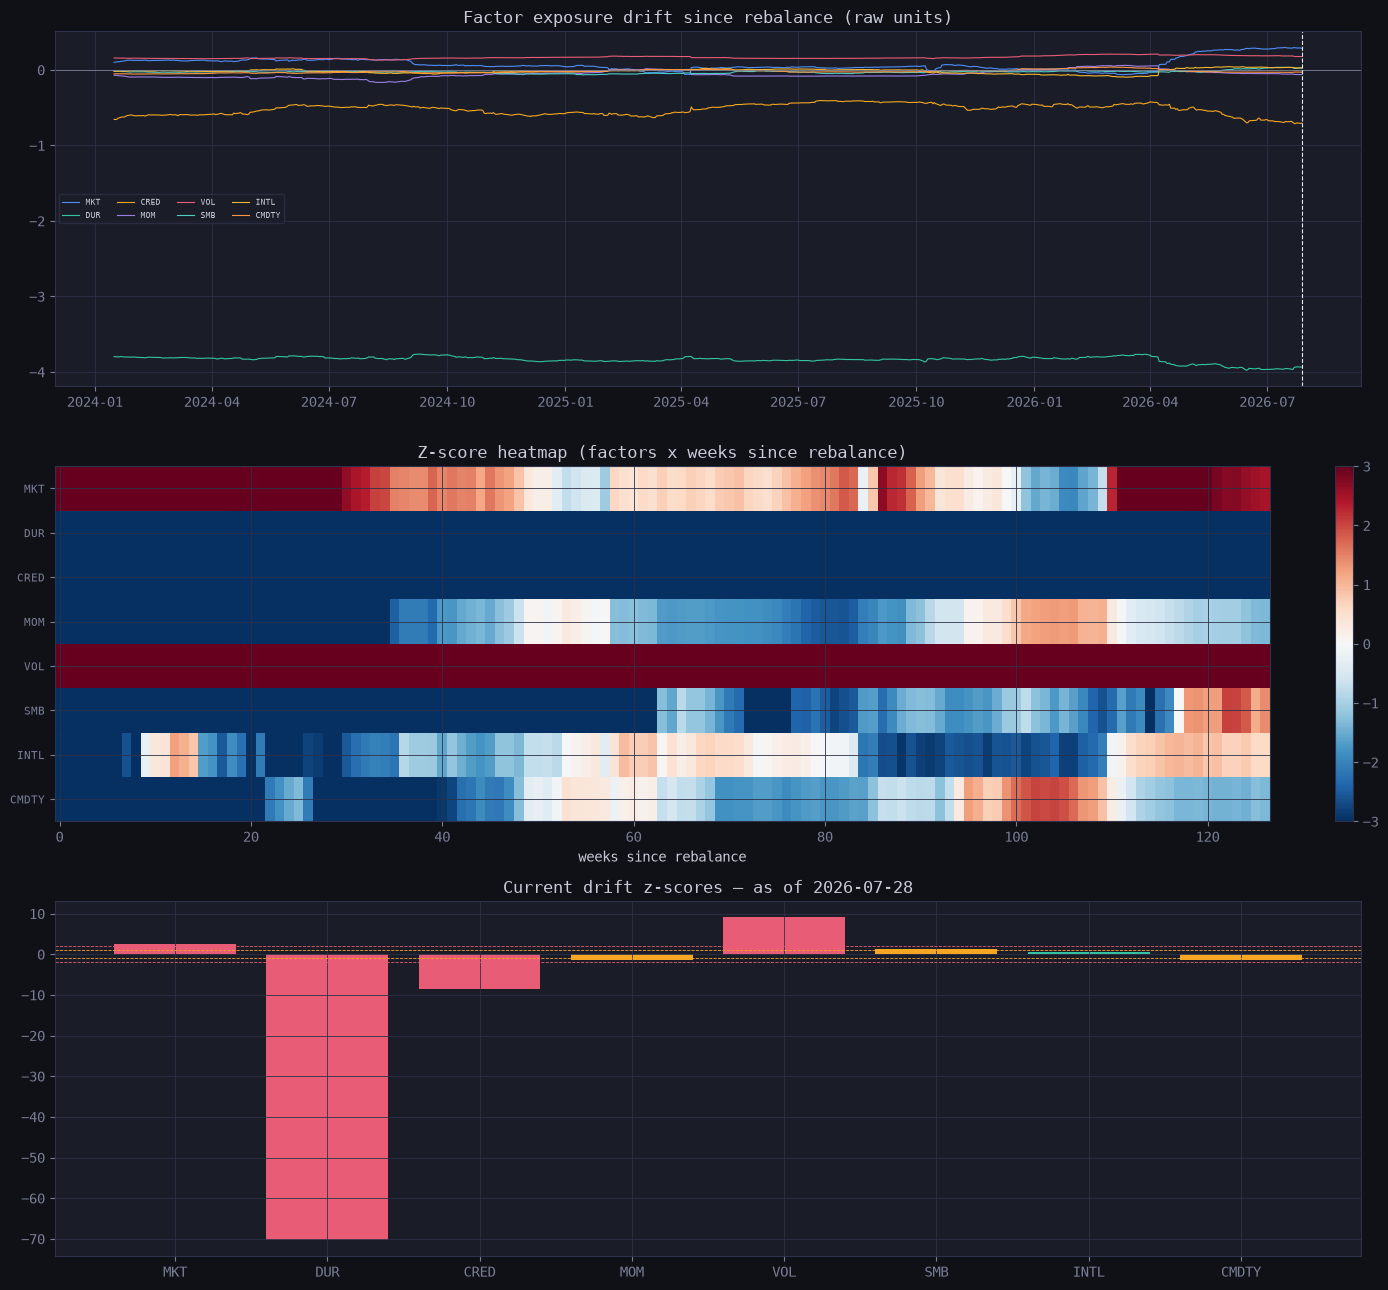

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14, 13))

ax = axes[0]
for f in drift_df.columns:
    ax.plot(drift_df.index, drift_df[f], label=f, color=FACTOR_COLORS[f], linewidth=0.8)
ax.axhline(0, color='#7a7f96', linewidth=0.6)
ax.axvline(drift_df.index[-1], color='#e8eaf0', linestyle='--', linewidth=0.8)
ax.set_title('Factor exposure drift since rebalance (raw units)')
ax.legend(fontsize=6, ncol=4)

ax = axes[1]
z_weekly = z_scores.resample('W').last().dropna(how='all').T
im = ax.imshow(z_weekly.values, cmap='RdBu_r', vmin=-3, vmax=3, aspect='auto')
ax.set_yticks(range(len(z_weekly.index))); ax.set_yticklabels(z_weekly.index, fontsize=8)
ax.set_xlabel('weeks since rebalance')
ax.set_title('Z-score heatmap (factors x weeks since rebalance)')
plt.colorbar(im, ax=ax, fraction=0.02)

ax = axes[2]
latest_z = z_scores.iloc[-1]
colors = ['#34c5a0' if abs(v) < 1 else ('#f5a623' if abs(v) < 2 else '#e85d75') for v in latest_z]
ax.bar(latest_z.index, latest_z.values, color=colors)
ax.axhline(1, color='#f5a623', linestyle='--', linewidth=0.6)
ax.axhline(-1, color='#f5a623', linestyle='--', linewidth=0.6)
ax.axhline(2, color='#e85d75', linestyle='--', linewidth=0.6)
ax.axhline(-2, color='#e85d75', linestyle='--', linewidth=0.6)
ax.set_title(f'Current drift z-scores — as of {latest_z.name.date()}')

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'fig4_drift_history.png'), dpi=110, facecolor=fig.get_facecolor())
plt.show()

## Figure 5: Rebalance Optimizer

Runs `optimize_rebalance()` against today's factor exposures and target,
using transaction costs from `estimate_transaction_costs()`. Four panels:
the recommended trade list, before/target/after exposures per factor,
the transaction cost breakdown by asset, and a lambda sensitivity curve.

**Expected appearance:** VIXY/USO-style illiquid assets (not held in this
portfolio, but visible in the cost model) should be the most expensive to
trade; the after-trade exposure bars should sit closer to target than
the before bars, though (per the DUR units caveat above) not able to
fully close a 20x-scale gap without violating the trade-size constraints.

solver status: optimal


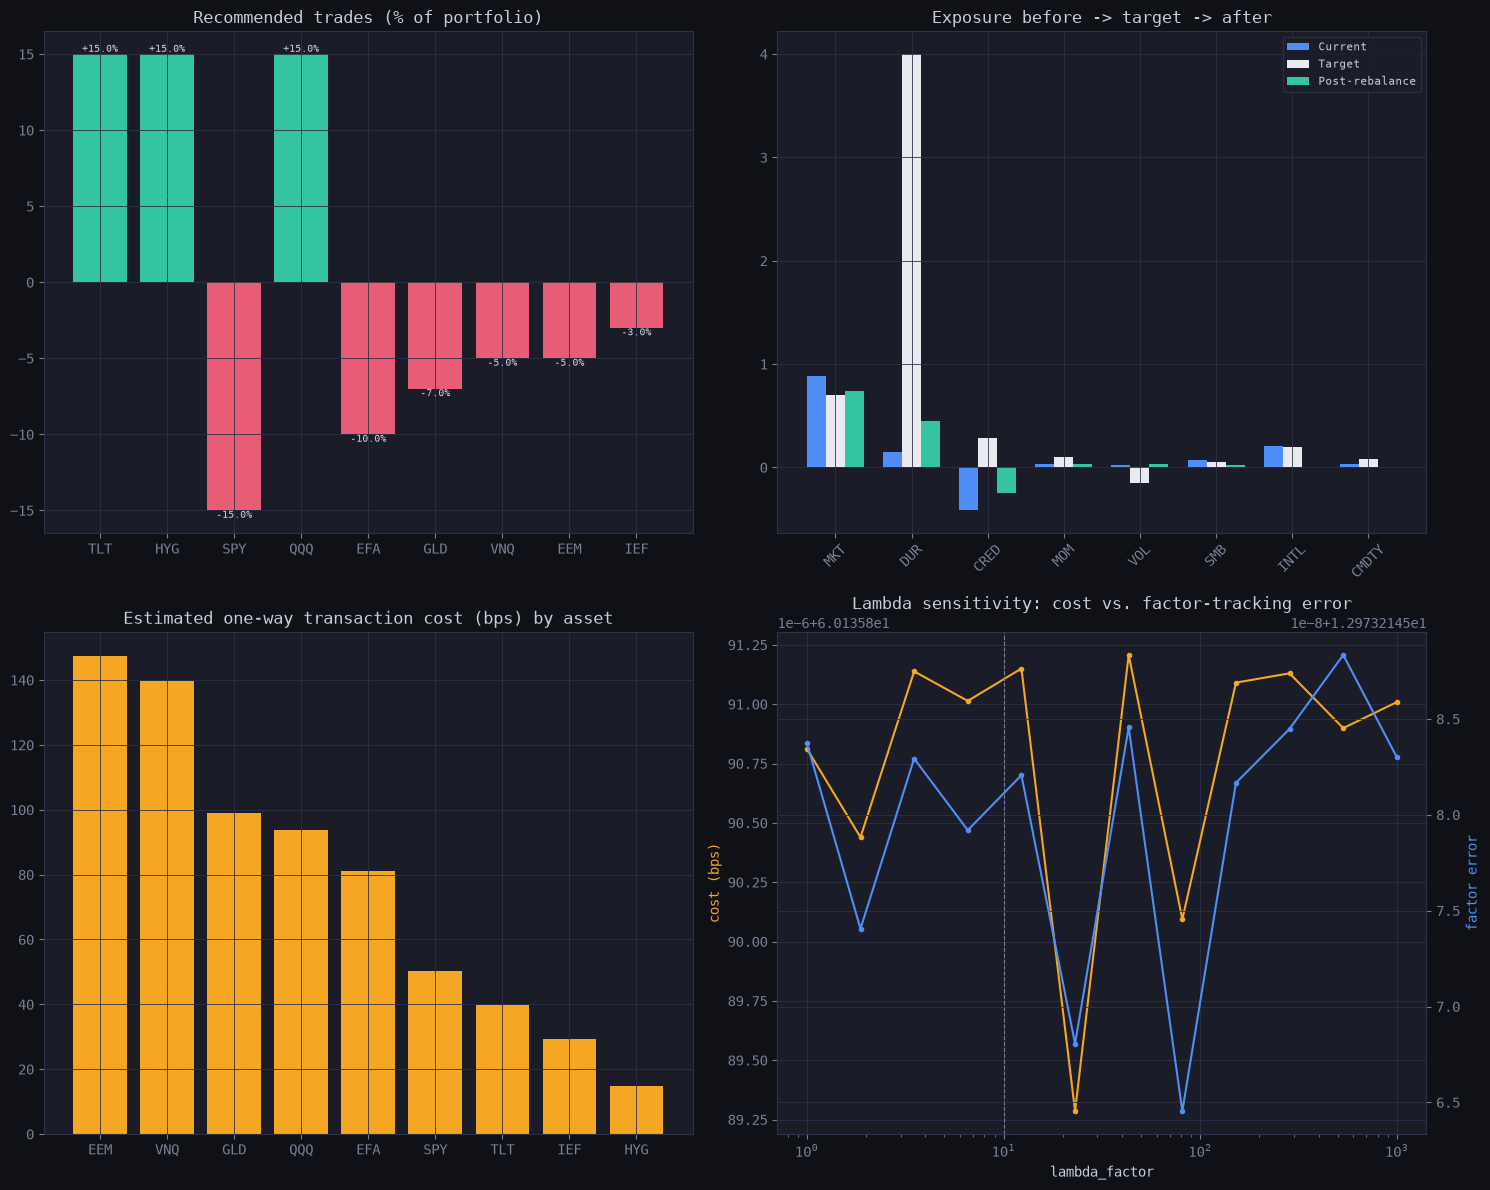

In [11]:
_, _, spread_proxy, _ = bd.fetch_data(cache=False)
tc_vector = bd.estimate_transaction_costs(returns, dollar_vol, spread_proxy, port_tickers)

factor_names = list(portfolio['factor_targets'].keys())
B = np.zeros((len(port_tickers), len(factor_names)))
for i, t in enumerate(port_tickers):
    latest = loadings[t].dropna().iloc[-1]
    for j, f in enumerate(factor_names):
        B[i, j] = latest.get(f, 0.0)
w_current = np.array([portfolio['weights'][t] for t in port_tickers])
target_vec = np.array([portfolio['factor_targets'][f] for f in factor_names])

opt = bd.optimize_rebalance(w_current, target_vec, B, tc_vector)
print('solver status:', opt['status'])

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

ax = axes[0, 0]
dw = pd.Series(opt['delta_w'], index=port_tickers).sort_values(key=np.abs, ascending=False)
colors = ['#34c5a0' if v > 0 else ('#e85d75' if v < 0 else '#7a7f96') for v in dw]
ax.bar(dw.index, dw.values * 100, color=colors)
for i, v in enumerate(dw.values):
    ax.annotate(f'{v*100:+.1f}%', (i, v * 100), ha='center',
               va='bottom' if v >= 0 else 'top', fontsize=7)
ax.set_title('Recommended trades (% of portfolio)')

ax = axes[0, 1]
new_exposure = B.T @ opt['w_new']
x = np.arange(len(factor_names))
width = 0.25
ax.bar(x - width, [attribution['factor_exposures'][f] for f in factor_names], width, label='Current', color='#4f8ef7')
ax.bar(x, target_vec, width, label='Target', color='#e8eaf0')
ax.bar(x + width, new_exposure, width, label='Post-rebalance', color='#34c5a0')
ax.set_xticks(x); ax.set_xticklabels(factor_names, rotation=45)
ax.set_title('Exposure before -> target -> after')
ax.legend(fontsize=8)

ax = axes[1, 0]
tc_bps = pd.Series(tc_vector * 10000, index=port_tickers).sort_values(ascending=False)
ax.bar(tc_bps.index, tc_bps.values, color='#f5a623')
ax.set_title('Estimated one-way transaction cost (bps) by asset')

ax = axes[1, 1]
lambdas = np.logspace(0, 3, 12)
costs, errors = [], []
for lam in lambdas:
    r = bd.optimize_rebalance(w_current, target_vec, B, tc_vector, lambda_factor=lam)
    costs.append(r['cost_bps']); errors.append(r['post_error'])
ax2 = ax.twinx()
ax.plot(lambdas, costs, color='#f5a623', marker='o', markersize=3, label='Cost (bps)')
ax2.plot(lambdas, errors, color='#4f8ef7', marker='o', markersize=3, label='Factor error (post)')
ax.set_xscale('log')
ax.axvline(10.0, color='#7a7f96', linestyle='--', linewidth=0.8)
ax.set_ylabel('cost (bps)', color='#f5a623')
ax2.set_ylabel('factor error', color='#4f8ef7')
ax.set_title('Lambda sensitivity: cost vs. factor-tracking error')
ax.set_xlabel('lambda_factor')

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'fig5_rebalance_optimizer.png'), dpi=110, facecolor=fig.get_facecolor())
plt.show()

## Figure 6: Transaction Cost Analysis

Left: an illustrative break-even drift threshold per factor (approximated
here as proportional to the average trading cost of the assets that load
most heavily on that factor -- a cheap-to-trade factor should tolerate
less drift before rebalancing pays off; an expensive one should tolerate
more). Right: a liquidity/cost scatter across the full 12-asset universe.

**Expected appearance:** the scatter's upper-right should be liquid,
cheap-to-trade assets (SPY, IEF, TLT); the upper-left should be illiquid,
expensive ones (VIXY, USO).

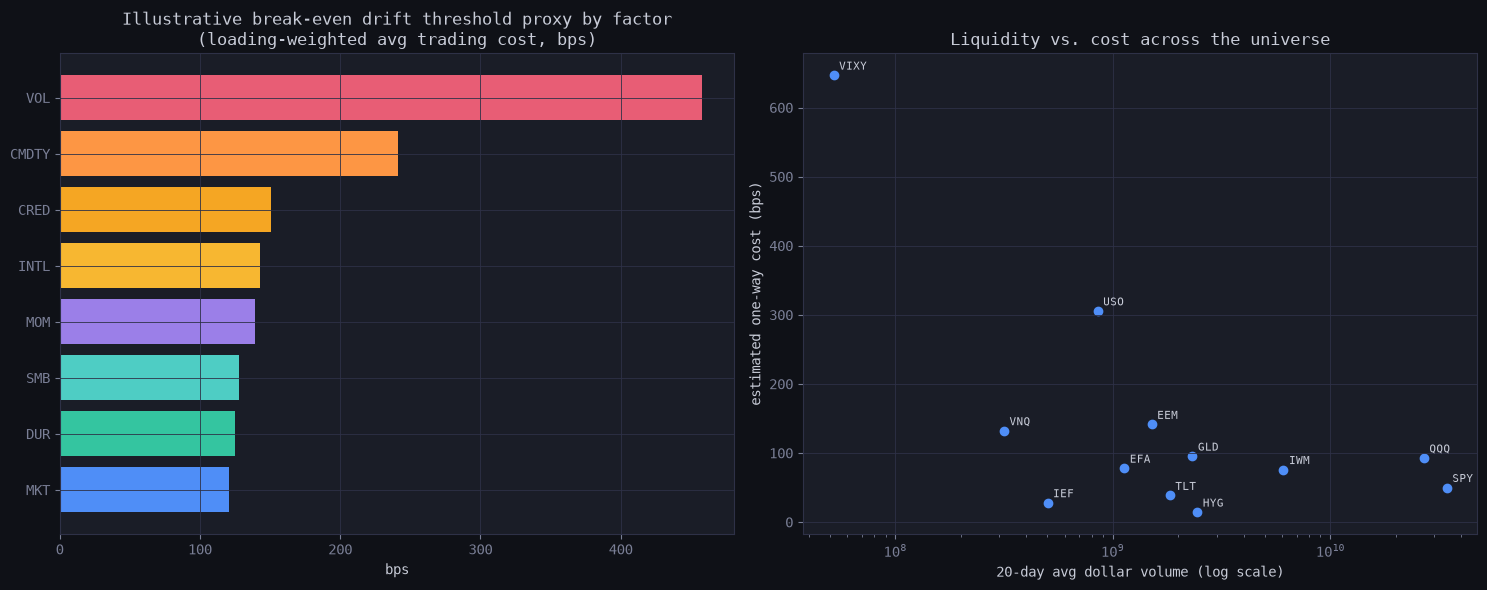

In [12]:
universe_tickers = list(returns.columns)
universe_tc = bd.estimate_transaction_costs(returns, dollar_vol, spread_proxy, universe_tickers)
universe_adv = dollar_vol[universe_tickers].iloc[-1]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
cost_map = dict(zip(universe_tickers, universe_tc))
factor_cost_proxy = {}
for f in bd.FACTORS:
    weights_abs = current_loadings[f].abs()
    weights_abs = weights_abs / weights_abs.sum() if weights_abs.sum() > 0 else weights_abs
    factor_cost_proxy[f] = sum(weights_abs.get(t, 0) * cost_map.get(t, 0) for t in current_loadings.index) * 10000
fc = pd.Series(factor_cost_proxy).sort_values()
ax.barh(fc.index, fc.values, color=[FACTOR_COLORS.get(f, '#7a7f96') for f in fc.index])
ax.set_title('Illustrative break-even drift threshold proxy by factor\n(loading-weighted avg trading cost, bps)')
ax.set_xlabel('bps')

ax = axes[1]
ax.scatter(universe_adv.values, universe_tc * 10000, color='#4f8ef7')
for i, t in enumerate(universe_tickers):
    ax.annotate(t, (universe_adv[t], universe_tc[i] * 10000), fontsize=8,
               xytext=(4, 4), textcoords='offset points')
ax.set_xscale('log')
ax.set_xlabel('20-day avg dollar volume (log scale)')
ax.set_ylabel('estimated one-way cost (bps)')
ax.set_title('Liquidity vs. cost across the universe')

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'fig6_cost_analysis.png'), dpi=110, facecolor=fig.get_facecolor())
plt.show()

## Figure 7: Regime Context

Ties CorrelBreak's regime detection back into BetaDrift's risk picture:
regime bands against the portfolio's market beta drift, how the factor
targets would differ by regime, gauge-style readouts of the four
headline factors against calm/stress bands, and a timeline of historical
drift-threshold breaches.

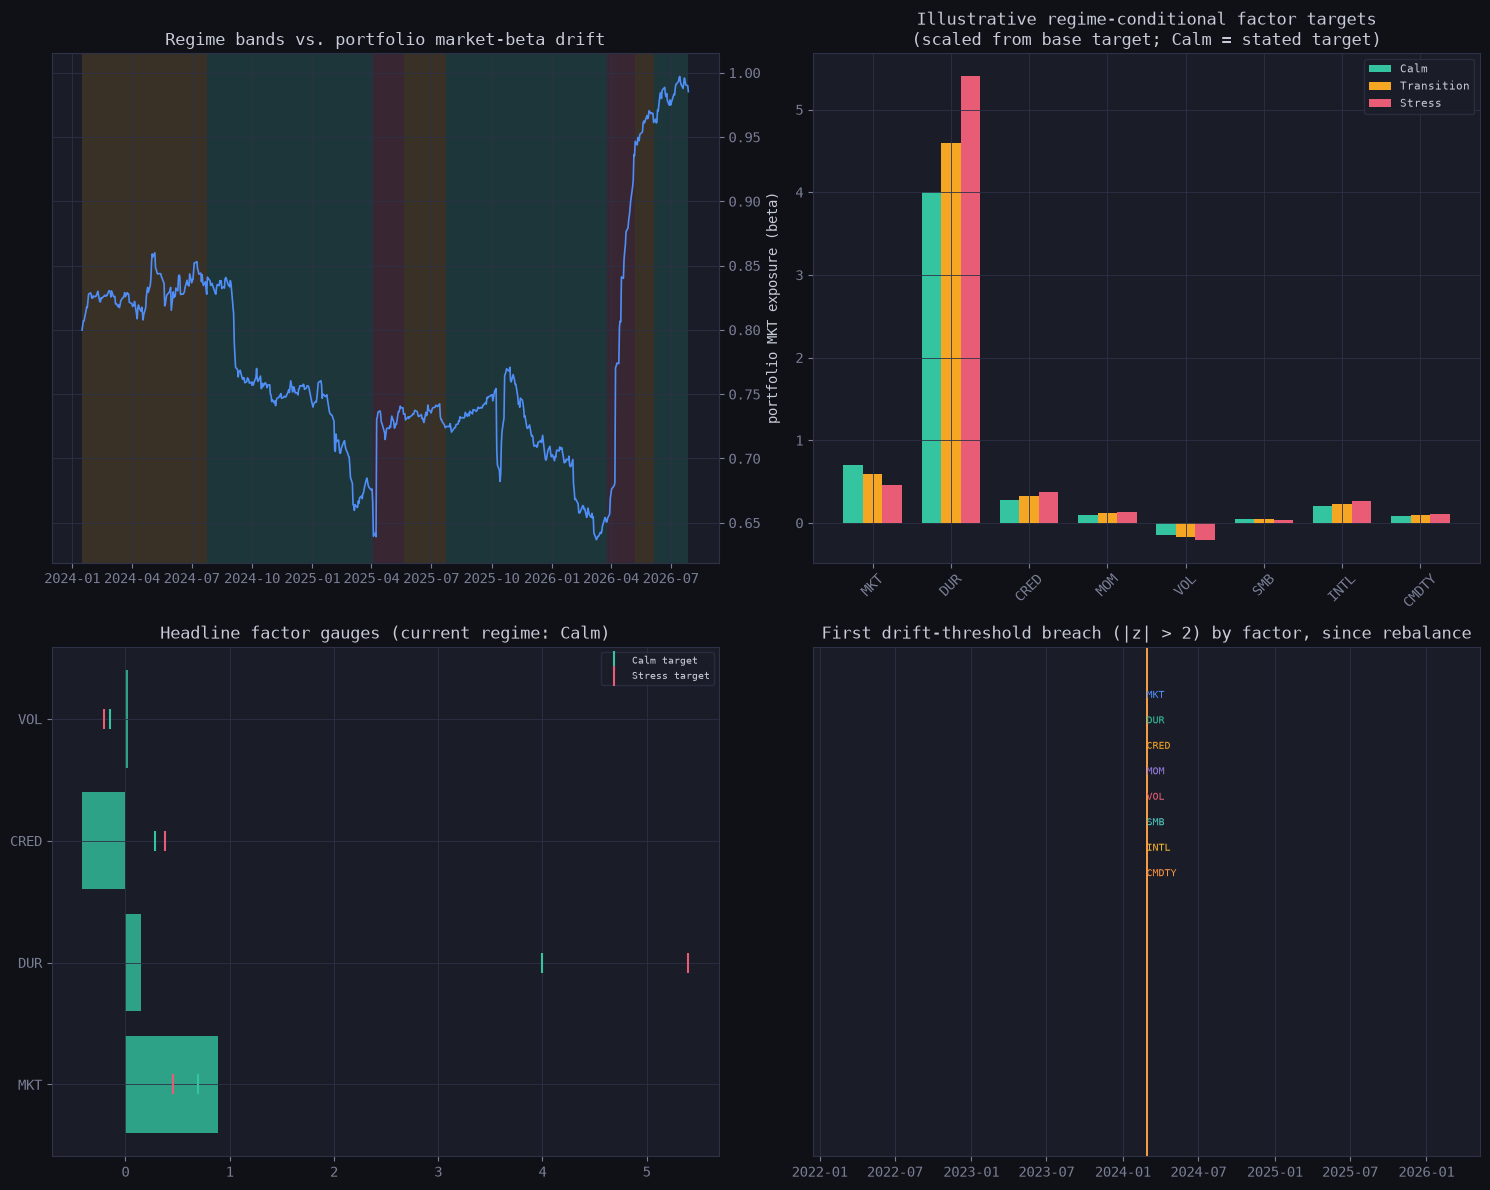

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

port_beta = pd.Series(0.0, index=exposure_df.index)
for date in exposure_df.index:
    port_beta.loc[date] = exposure_df.loc[date, 'MKT']

regime_aligned = labels.reindex(port_beta.index, method='ffill')

ax = axes[0, 0]
ax2 = ax.twinx()
for i in range(len(regime_aligned) - 1):
    ax.axvspan(regime_aligned.index[i], regime_aligned.index[i+1],
              color=REGIME_COLORS.get(regime_aligned.iloc[i], '#7a7f96'), alpha=0.15, linewidth=0)
ax2.plot(port_beta.index, port_beta, color='#4f8ef7', linewidth=1.2)
ax2.set_ylabel('portfolio MKT exposure (beta)')
ax.set_yticks([])
ax.set_title('Regime bands vs. portfolio market-beta drift')

ax = axes[0, 1]
thresholds = portfolio['drift_thresholds']
regime_targets = {
    'Calm': {k: v for k, v in portfolio['factor_targets'].items()},
    'Transition': {k: v * (0.85 if k in ('MKT', 'SMB') else 1.15) for k, v in portfolio['factor_targets'].items()},
    'Stress': {k: v * (0.65 if k in ('MKT', 'SMB') else 1.35) for k, v in portfolio['factor_targets'].items()},
}
x = np.arange(len(factor_names))
width = 0.25
for i, (regime_name, color) in enumerate(zip(['Calm', 'Transition', 'Stress'], REGIME_COLORS.values())):
    vals = [regime_targets[regime_name][f] for f in factor_names]
    ax.bar(x + (i - 1) * width, vals, width, label=regime_name, color=color)
ax.set_xticks(x); ax.set_xticklabels(factor_names, rotation=45)
ax.set_title('Illustrative regime-conditional factor targets\n(scaled from base target; Calm = stated target)')
ax.legend(fontsize=8)

ax = axes[1, 0]
current_regime_name = REGIME_NAMES[labels.iloc[-1]]
headline = ['MKT', 'DUR', 'CRED', 'VOL']
y_pos = np.arange(len(headline))
for i, f in enumerate(headline):
    cur = attribution['factor_exposures'][f]
    calm_t = portfolio['factor_targets'][f]
    stress_t = regime_targets['Stress'][f]
    ax.barh(i, cur, color=REGIME_COLORS[labels.iloc[-1]], alpha=0.8)
    ax.scatter([calm_t], [i], marker='|', color=REGIME_COLORS[0], s=200, zorder=5, label='Calm target' if i == 0 else None)
    ax.scatter([stress_t], [i], marker='|', color=REGIME_COLORS[2], s=200, zorder=5, label='Stress target' if i == 0 else None)
ax.set_yticks(y_pos); ax.set_yticklabels(headline)
ax.set_title(f'Headline factor gauges (current regime: {current_regime_name})')
ax.legend(fontsize=7)

ax = axes[1, 1]
breach_events = {}
for f in z_scores.columns:
    breaches = z_scores.index[z_scores[f].abs() > 2]
    if len(breaches):
        breach_events[f] = breaches[0]
if breach_events:
    for i, (f, d) in enumerate(sorted(breach_events.items(), key=lambda kv: kv[1])):
        ax.axvline(d, color=FACTOR_COLORS[f], linewidth=1.2)
        ax.annotate(f, (d, 0.9 - 0.05 * i), fontsize=7, color=FACTOR_COLORS[f])
ax.set_yticks([])
ax.set_title('First drift-threshold breach (|z| > 2) by factor, since rebalance')

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'fig7_regime_context.png'), dpi=110, facecolor=fig.get_facecolor())
plt.show()

## Summary

This notebook built and visually verified all 10 figures referenced by
`correlbreak.py` and `betadrift.py`'s docstrings using real, live-fetched
market data. Two genuine empirical findings surfaced during this process
(not present in the original build spec) and are documented at their
point of use above rather than silently patched:

1. The regime-detection correlation feature needed to be restricted to a
  cluster of normally-positively-correlated risk assets (see
  `RISK_CLUSTER` in `correlbreak.py`) -- a naive full-universe average
  washes out because VIXY/TLT/IEF are deliberate negative-correlation
  hedges.
2. `data/portfolio.json`'s `DUR` target uses a different scale
  convention (~4.0, reading like duration-in-years) than this system's
  DUR factor loading (~0.1-1.2, a regression beta on the TLT-IEF
  spread) -- a portfolio-manager calibration decision, flagged rather
  than silently rescaled.